In [2]:
# import numpy as np
# import matplotlib.pyplot as plt 
# import torch
# frequencies = np.geomspace(1, 1024, num=11)
# scale = np.repeat(2 * np.pi * frequencies /10, 2)
# bias = np.tile(np.array([0, np.pi / 2]), 11)

import torch

bias = torch.tensor([1.0, 2.0, 3.0])
scale = torch.tensor([0.1, 0.2, 0.3])
t = torch.tensor([[10.0, 20.0, 30.0], [40.0, 50.0, 60.0]])
t = t[..., None]

# # Ensure the dimensions match for broadcasting
bias = bias[..., None]  # Shape: [1, 3]
scale = scale[..., None]  # Shape: [1, 3]

result = torch.addcmul(bias, scale, t)
result = result.squeeze(-1)
print(result)


tensor([[ 2.,  6., 12.],
        [ 5., 12., 21.]])


In [3]:
import torch

# Simulation parameters
simulation_steps = 5
batch_size = 10  # Number of sequences in the batch

def test_simulation_steps():
    # Generate x_0 mock object with a time attribute
    class MockX0:
        def __init__(self, batch_size, device):
            self.time = torch.zeros((batch_size,), device=device)

    # Create a mock x_0 object
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_0 = MockX0(batch_size=batch_size, device=device)
    print(x_0.time)

    # Generate n values
    inst

    print("Generated n values:", n.cpu().numpy())

# Run the test
test_simulation_steps()


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')


NameError: name 'inst' is not defined

Generated n values: [0.03917663 0.7516183  0.13329303 0.9209098  0.5732237  0.32989994
 0.19428547 0.11781672 0.73487395 0.78472817]


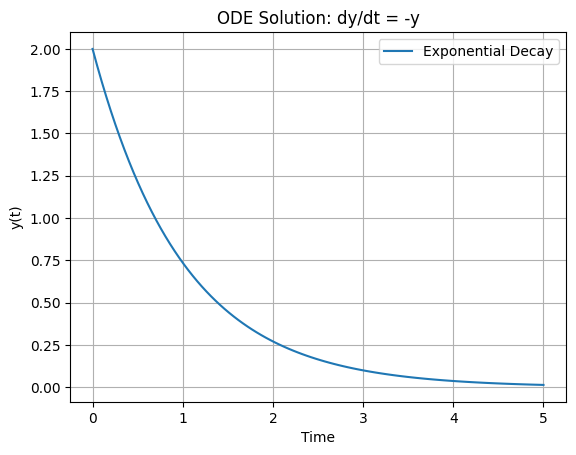

In [2]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint

# Simulation parameters
simulation_steps = 5
batch_size = 10  # Number of sequences in the batch

def ode_function(t, y):
    """
    Example ODE function: dy/dt = -y (Exponential decay)
    """
    return -y

def test_simulation_steps():
    # Generate x_0 mock object with a time attribute
    class MockX0:
        def __init__(self, batch_size, device):
            self.time = torch.zeros((batch_size,), device=device)

    # Create a mock x_0 object
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_0 = MockX0(batch_size=batch_size, device=device)

    # Generate n values uniformly between 0 and 1
    n = torch.rand(size=(len(x_0.time),), device=x_0.time.device)

    print("Generated n values:", n.cpu().numpy())

    # Solve the ODE
    y0 = torch.tensor([2.0])  # Initial condition
    t = torch.linspace(0, 5, 100)  # Time points
    traj = odeint(ode_function, y0, t)

    # Plot the solution
    plt.plot(t.cpu().numpy(), traj.cpu().numpy(), label="Exponential Decay")
    plt.xlabel("Time")
    plt.ylabel("y(t)")
    plt.title("ODE Solution: dy/dt = -y")
    plt.legend()
    plt.grid()
    plt.show()

# Run the test
test_simulation_steps()


In [6]:
from typing import Union

import torch
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked

from add_thin.data import Batch

patch_typeguard()  # use before @typechecked


@typechecked
def generate_hpp(
    tmax: TensorType,
    n_sequences: int,
    intensity: Union[TensorType, None] = None,
):
    """
    Generate a batch of sequences from a homogeneous Poisson process on [0,T].

    Parameters
    ----------
    tmax : TensorType
        Maximum time of the sequence
    n_sequences : int
        Number of sequences to generate
    intensity : Union[TensorType, None], optional
        Intensity of the process, set to 1 if None, by default None

    Returns
    -------
    Batch
        Batch of generated sequences
    """
    device = tmax.device
    if intensity is None:
        intensity = torch.ones(n_sequences, device=device)

    # Get number of samples
    n_samples = torch.poisson(tmax * intensity)
    max_samples = int(torch.max(n_samples).item()) + 1

    # Sample times
    times = torch.rand((n_sequences, max_samples), device=device) * tmax

    # Mask for padding events
    mask = (
        torch.arange(0, max_samples, device=device)[None, :]
        < n_samples[:, None]
    )
    times = times * mask

    assert (mask.sum(-1) == n_samples).all(), "wrong number of samples"
    return Batch.remove_unnescessary_padding(
        time=times, mask=mask, tmax=tmax, kept=None
    )


2


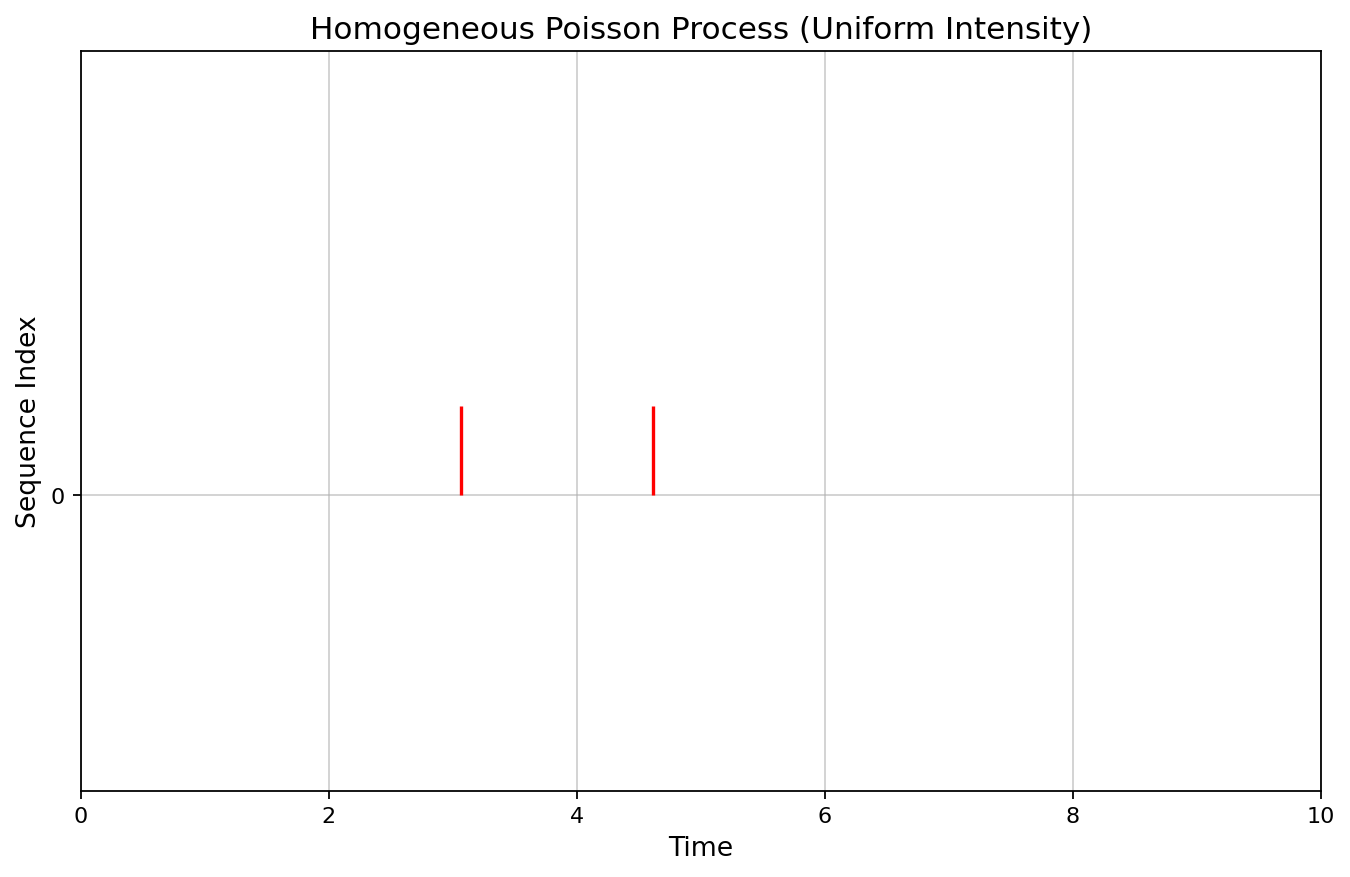

In [76]:
import matplotlib.pyplot as plt
import torch

# Assuming generate_hpp is already defined and data is generated
tmax = torch.tensor(10)  # Maximum time
n_sequences = 1         # Number of sequences
intensity = torch.ones(n_sequences) * 0.1  # Uniform intensity

# Generate data (assuming generate_hpp is defined)
data = generate_hpp(tmax=tmax, n_sequences=n_sequences, intensity=intensity)

# Extract times and mask
times = data.time
mask = data.mask

# Visualization
plt.figure(figsize=(10, 6), dpi=160)
for i in range(n_sequences):
    valid_times = times[i][mask[i]].cpu().numpy()  # Extract valid event times
    print(len(valid_times))
    plt.vlines(valid_times, i , i + 0.6, colors='red', label=f"Sequence {i + 1}")

plt.title("Homogeneous Poisson Process (Uniform Intensity)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Sequence Index", fontsize=12)
plt.yticks(range(n_sequences))
plt.xlim(0, 10)
plt.ylim(-2, 3)
plt.grid(True, alpha=0.6)
plt.show()


In [93]:
tmax = torch.tensor(10)  # Maximum time
n_sequences = 1     # Number of sequences
intensity = torch.ones(n_sequences) * 3  # Uniform intensity

tests = 10000
avg_n_samples = 0
for i in range(tests): 
    data = generate_hpp(tmax=tmax, n_sequences=n_sequences, intensity=intensity)
    avg_n_samples += data.mask.sum(-1).item()

print(avg_n_samples / tests)


30.0064


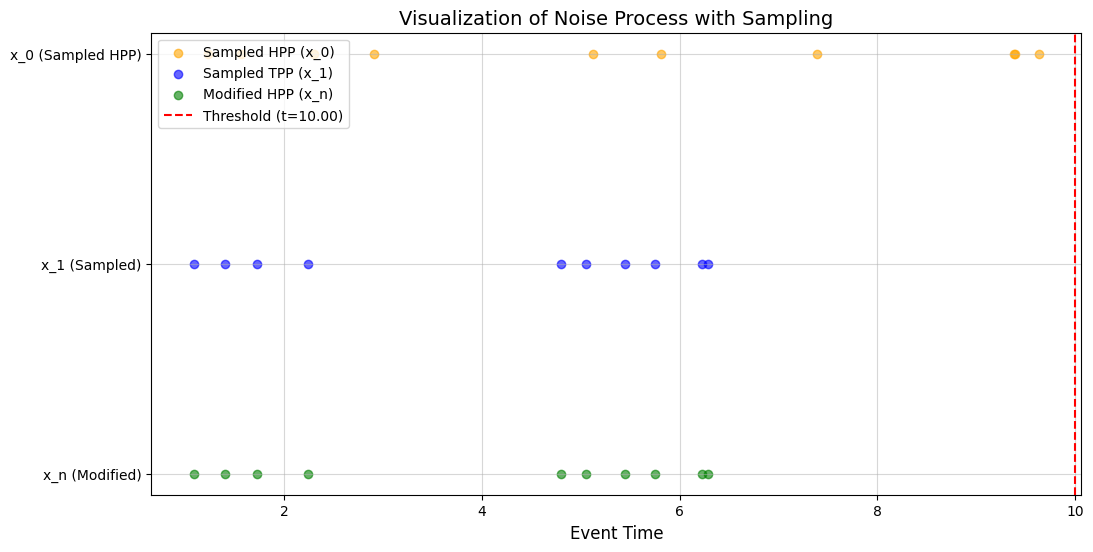

In [97]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def sample_hpp(tmax, n_sequences, rate=1.0):
    """Generates a homogeneous Poisson process."""
    return [torch.sort(torch.rand(int(rate * tmax), device='cpu') * tmax).values for _ in range(n_sequences)]

def plot_noise_process_with_sampling(x_0_sampled, x_1_sampled, x_n, n, tmax):
    """
    Plot the sampled HPP (x_0), original TPP (x_1), and modified HPP (x_n).

    Parameters:
    ----------
    x_0_sampled : List[Tensor]
        Sampled homogeneous Poisson processes.
    x_1_sampled : List[Tensor]
        Sampled original temporal point process data.
    x_n : List[Tensor]
        Modified HPP with original TPP data.
    n : Tensor
        Thresholds for event replacement (scaled time).
    tmax : float
        Maximum time for the events.
    """
    batch_index = 0  # Visualize for the first sequence in the batch
    t_threshold = n[batch_index].item() * tmax

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot sampled HPP (x_0)
    ax.scatter(
        x_0_sampled[batch_index].cpu().numpy(),
        np.ones_like(x_0_sampled[batch_index].cpu().numpy()) * 3,
        label="Sampled HPP (x_0)",
        color="orange",
        alpha=0.6,
    )

    # Plot sampled TPP (x_1)
    ax.scatter(
        x_1_sampled[batch_index].cpu().numpy(),
        np.ones_like(x_1_sampled[batch_index].cpu().numpy()) * 2,
        label="Sampled TPP (x_1)",
        color="blue",
        alpha=0.6,
    )

    # Plot modified HPP (x_n)
    ax.scatter(
        x_n[batch_index].cpu().numpy(),
        np.ones_like(x_n[batch_index].cpu().numpy()) * 1,
        label="Modified HPP (x_n)",
        color="green",
        alpha=0.6,
    )

    # Add a vertical line for the time threshold
    ax.axvline(
        t_threshold,
        color="red",
        linestyle="--",
        label=f"Threshold (t={t_threshold:.2f})",
    )

    # Configure the plot
    ax.set_title("Visualization of Noise Process with Sampling", fontsize=14)
    ax.set_xlabel("Event Time", fontsize=12)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["x_n (Modified)", "x_1 (Sampled)", "x_0 (Sampled HPP)"])
    ax.legend(loc="upper left", fontsize=10)
    ax.grid(True, alpha=0.5)

    plt.show()


# Example: Sampling HPP, original data, and computing x_n
tmax = 10.0  # Max time
n_sequences = 1  # Batch size
rate = 1.0  # Event rate for HPP
n = torch.tensor([1])  # Threshold fraction for visualization

# Step 1: Sample HPP (x_0)
x_0_sampled = sample_hpp(tmax=tmax, n_sequences=n_sequences, rate=rate)

# Step 2: Sample original data (x_1) from HPP
x_1_sampled = sample_hpp(tmax=tmax, n_sequences=n_sequences, rate=rate)

# Step 3: Generate x_n (modified HPP with events from x_1)
x_n = []
for i in range(n_sequences):
    threshold_time = n[i].item() * tmax
    x_n_sequence = torch.cat([x_1_sampled[i][x_1_sampled[i] <= threshold_time],
                              x_0_sampled[i][x_0_sampled[i] > threshold_time]])
    x_n.append(torch.sort(x_n_sequence).values)

# Visualize
plot_noise_process_with_sampling(x_0_sampled, x_1_sampled, x_n, n, tmax)


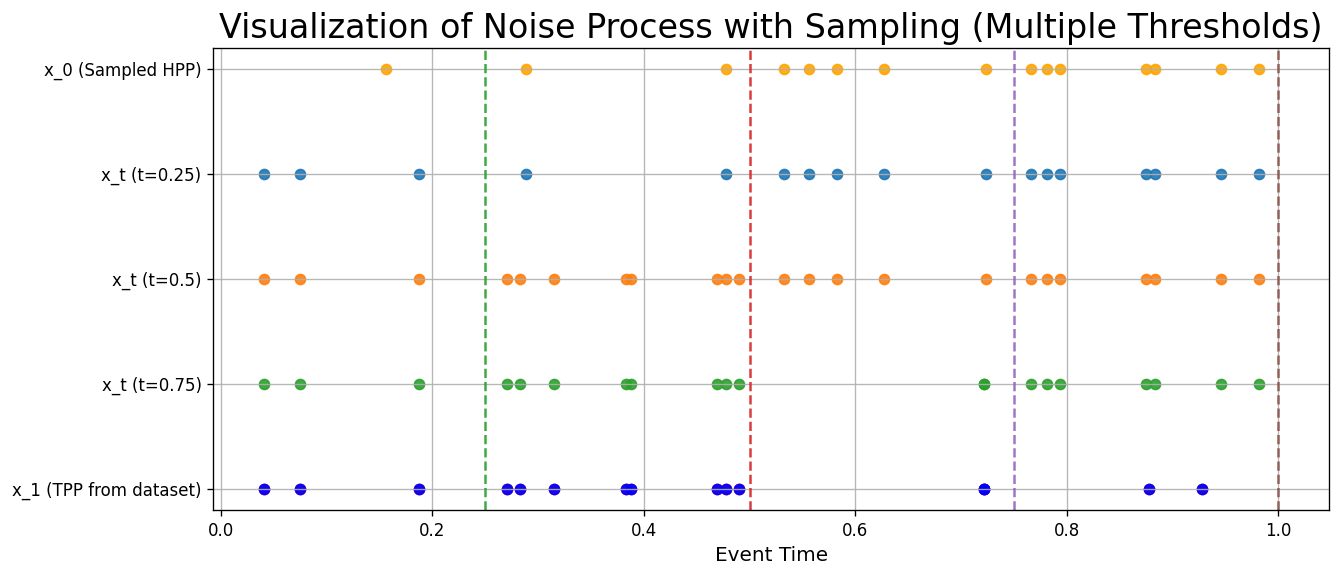

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def sample_hpp(tmax, n_sequences, rate=1.0):
    """Generates a homogeneous Poisson process."""
    return [torch.sort(torch.rand(int(rate * tmax), device='cpu') * tmax).values for _ in range(n_sequences)]

def plot_noise_process_with_sampling(x_0_sampled, x_1_sampled, x_ns, thresholds, tmax):
    """
    Plot the sampled HPP (x_0), original TPP (x_1), and modified HPP (x_ns) for different thresholds.

    Parameters:
    ----------
    x_0_sampled : List[Tensor]
        Sampled homogeneous Poisson processes.
    x_1_sampled : List[Tensor]
        Sampled original temporal point process data.
    x_ns : List[List[Tensor]]
        List of modified HPPs with original TPP data for each threshold.
    thresholds : List[float]
        Thresholds for event replacement (scaled time fractions).
    tmax : float
        Maximum time for the events.
    """
    batch_index = 0  # Visualize for the first sequence in the batch

    fig, ax = plt.subplots(figsize=(12, 5),dpi = 120)

    # Plot sampled HPP (x_0)
    ax.scatter(
        x_0_sampled[batch_index].cpu().numpy(),
        np.ones_like(x_0_sampled[batch_index].cpu().numpy()) * 5,
        label="Sampled HPP (x_0)",
        color="orange",
        alpha=0.9,
    )

    # Plot modified HPPs (x_ns) for each threshold
    y_offset = 4
    for idx, (x_n, threshold) in enumerate(zip(x_ns, thresholds)):
        ax.scatter(
            x_n[batch_index].cpu().numpy(),
            np.ones_like(x_n[batch_index].cpu().numpy()) * y_offset,
            label=f"x_n (t={threshold:.2f})",
            alpha=0.9,
        )
        # Add a vertical line for the time threshold
        ax.axvline(
            threshold * tmax,
            color=f"C{idx + 2}",
            linestyle="--",
            alpha=0.9,
            label=f"Threshold (t={threshold:.2f})",
        )
        y_offset -= 1

    # Plot sampled TPP (x_1) last
    ax.scatter(
        x_1_sampled[batch_index].cpu().numpy(),
        np.ones_like(x_1_sampled[batch_index].cpu().numpy()) * 1,
        label="Sampled TPP (x_1)",
        color="blue",
        alpha=0.9,
    )

    # Configure the plot
    ax.set_title("Visualization of Noise Process with Sampling (Multiple Thresholds)", fontsize=20)
    ax.set_xlabel("Event Time", fontsize=12)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["x_1 (TPP from dataset)", "x_t (t=0.75)", "x_t (t=0.5)", "x_t (t=0.25)", "x_0 (Sampled HPP)"])
    ax.grid(True, alpha=0.9)

    plt.show()


# Example: Sampling HPP, original data, and computing x_n for multiple thresholds
tmax = 1.0  # Max time
n_sequences = 1  # Batch size
rate = 15.0  # Event rate for HPP
thresholds = [0.25, 0.5, 0.75, 1.0]  # Time thresholds as fractions of tmax

# Step 1: Sample HPP (x_0)
x_0_sampled = sample_hpp(tmax=tmax, n_sequences=n_sequences, rate=rate)

# Step 2: Sample original data (x_1) from HPP
x_1_sampled = sample_hpp(tmax=tmax, n_sequences=n_sequences, rate=rate)

# Step 3: Generate x_ns (modified HPPs with events from x_1 for each threshold)
x_ns = []
for threshold in thresholds:
    x_n = []
    for i in range(n_sequences):
        threshold_time = threshold * tmax
        x_n_sequence = torch.cat([x_1_sampled[i][x_1_sampled[i] <= threshold_time],
                                  x_0_sampled[i][x_0_sampled[i] > threshold_time]])
        x_n.append(torch.sort(x_n_sequence).values)
    x_ns.append(x_n)

# Visualize
plot_noise_process_with_sampling(x_0_sampled, x_1_sampled, x_ns, thresholds, tmax)


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

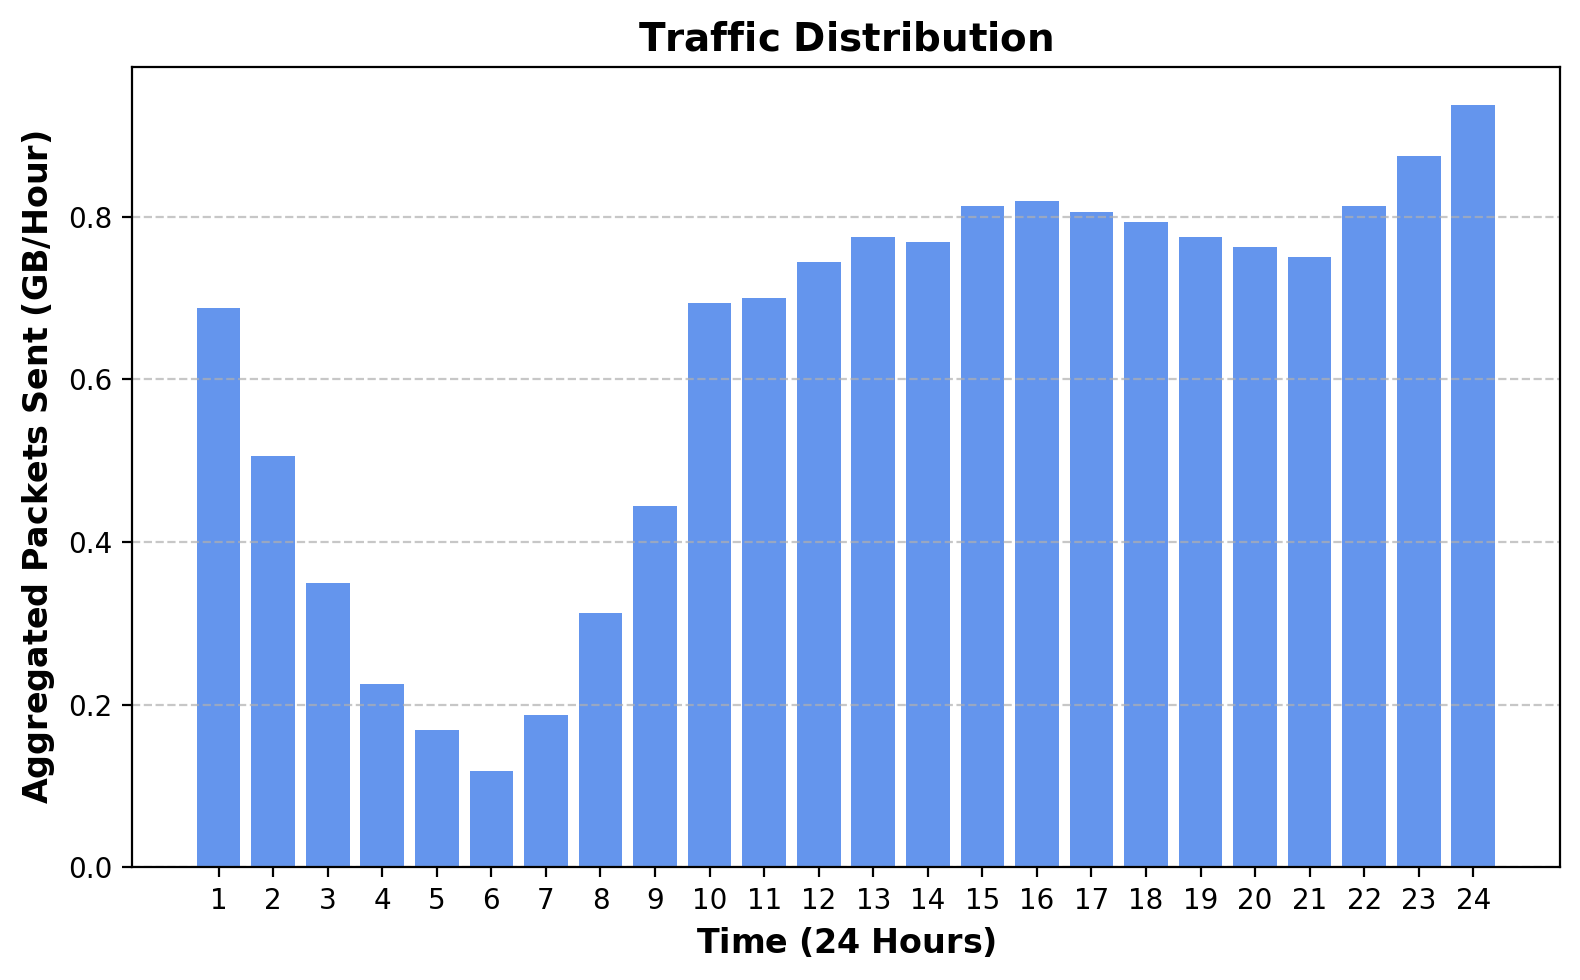

In [21]:
import matplotlib.pyplot as plt
# setup_text_plots(fontsize=8)
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "Helvetica",

})

def plot_distribution():
    distribution = [
        11.0, 8.1, 5.6, 3.6, 2.7, 1.9, 3.0, 5.0, 7.1, 11.1, 11.2, 11.9,
        12.4, 12.3, 13.0, 13.1, 12.9, 12.7, 12.4, 12.2, 12.0, 13.0, 14.0, 15.0
    ]

    # Normalize the distribution
    normalized_distribution = [val / 16 for val in distribution]

    # Plotting the histogram with 24 points
    plt.figure(figsize=(8, 5),dpi = 200)
    plt.bar(range(1, 25), normalized_distribution, color='cornflowerblue', alpha=1)
    
    # Title and labels with mathtext formatting
    plt.title(r'$\mathbf{Traffic\ Distribution}$', fontsize=14)
    plt.xlabel(r'$\mathbf{Time\ (24\ Hours)}$', fontsize=12)
    plt.ylabel(r'$\mathbf{Aggregated\ Packets\ Sent\ (GB/Hour)}$', fontsize=12)
    
    # Grid and ticks
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(range(1, 25))

    # Show the plot
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_distribution()

In [9]:
plt.rcdefaults() 